In [1]:
from functools import partial
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy as jsp

import matplotlib as mpl
import matplotlib.pyplot as plt

# Set matplotlib parameters globally
mpl.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 12,
    'axes.labelsize': 18,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'lines.linewidth': 2.0
})

In [2]:
rng_key = jr.PRNGKey(42)

In [194]:
sigma = 1.0

def f(t, x):
    return jnp.zeros_like(x)

def f_star(t, x, T, xT):
    return (xT - x) / (T - t + 1e-8)

def f_reverse(t, x, T, x0):
    return (x0 - x) / (T - t + 1e-8)

def g(t, x):
    return sigma

In [3]:
def solve_sde(rng_key, f, g, x0, dt, n_steps):
    dWs = jr.normal(rng_key, shape=(n_steps, 1)) * jnp.sqrt(dt)
    
    def scan_body(carry, val):
        x, t = carry
        dW = val
        drift = f(t, x) * dt
        diffusion = g(t, x) * dW
        x_next = x + drift + diffusion
        t_next = t + dt
        return (x_next, t_next), x_next
        
    *_, xs = jax.lax.scan(
        scan_body,
        init=(x0, 0.0),
        xs=dWs,
        length=n_steps
    )
    xs = jnp.concatenate([x0[None], xs])
    return xs

In [195]:
x0 = jnp.array([0.0])
xT = jnp.array([0.0])

T = 1.0
dt = 0.001
ts = jnp.arange(0, T + dt, dt)
n_steps = int(T / dt)
n_samples = 5

rng_keys = jr.split(rng_key, n_samples)
xs = jax.vmap(
    solve_sde,
    in_axes=(0, None, None, None, None, None),
    out_axes=0
)(rng_keys, f, g, x0, dt, n_steps)
xs_star = jax.vmap(
    solve_sde,
    in_axes=(0, None, None, None, None, None),
    out_axes=0
)(rng_keys, partial(f_star, xT=xT, T=T), g, x0, dt, n_steps)
xs_reverse = jax.vmap(
    solve_sde,
    in_axes=(0, None, None, None, None, None),
    out_axes=0
)(rng_keys, partial(f_reverse, x0=x0, T=T), g, xT, dt, n_steps)

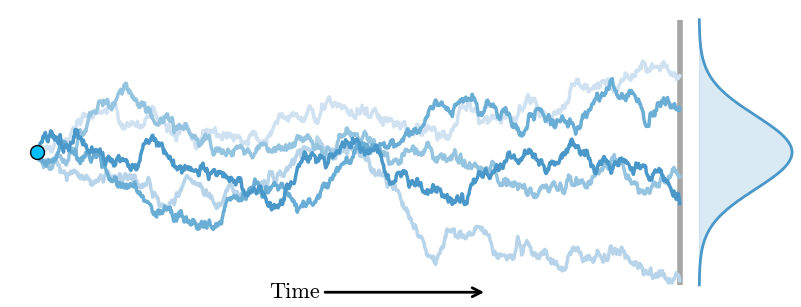

In [119]:
fig, axs = plt.subplot_mosaic([['.', '.'],
                               ["traj", "dist"]],
                              width_ratios=[1, 0.15],
                              layout='constrained',
                              sharey=True)
colors = plt.cm.Blues(jnp.linspace(0.2, 0.6, n_samples))  # Truncated colormap range

for i in range(n_samples):
    axs['traj'].plot(ts, xs[i], alpha=1.0, linewidth=2.5, color=colors[i], zorder=2)
    
axs['traj'].scatter(0.0, x0, marker='o', color='deepskyblue', s=100, edgecolors='black', zorder=10)
axs['traj'].vlines(x=T, ymin=-1.8, ymax=1.8, color='grey', alpha=0.7, linewidth=4.0, zorder=1)
axs['traj'].set_ylim(-2.0, 2.0)
axs['traj'].set_xlim(-0.05, T + 0.01)
axs['traj'].xaxis.set_visible(False)
axs['traj'].yaxis.set_visible(False)
# Add an arrow to indicate time direction
axs['traj'].annotate('Time', xy=(0.7, -1.9), xytext=(0.4, -1.9),
                        arrowprops=dict(arrowstyle='->', lw=2, color='black'),
                        fontsize=16, ha='center', va='center')

ys = jnp.linspace(-1.8, 1.8, 200)
pdfs = jsp.stats.norm.pdf(ys, loc=0.0, scale=0.5 * sigma * jnp.sqrt(T))
axs['dist'].plot(pdfs, ys, color=colors[-1])
axs['dist'].fill_betweenx(ys, 0.0, pdfs, color=colors[-1], alpha=0.2)
axs['dist'].xaxis.set_visible(False)
axs['dist'].yaxis.set_visible(False)
# Remove spines (frame) from both axes
for spine in ['top', 'right', 'bottom', 'left']:
    axs['traj'].spines[spine].set_visible(False)
    axs['dist'].spines[spine].set_visible(False)

plt.savefig('./assets/sde_paths.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show() 

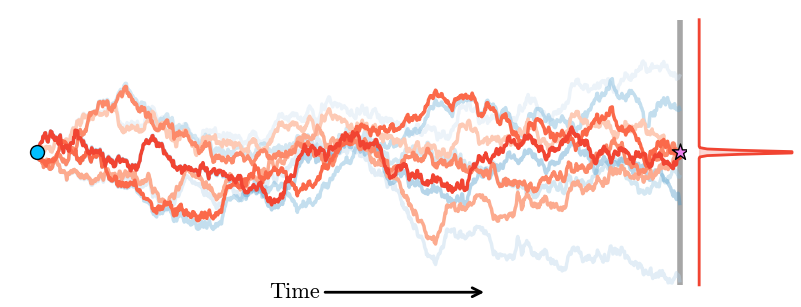

In [120]:
fig, axs = plt.subplot_mosaic([['.', '.'],
                               ["traj", "dist"]],
                              width_ratios=[1, 0.15],
                              layout='constrained',
                              sharey=True)
colors = plt.cm.Blues(jnp.linspace(0.2, 0.6, n_samples))  # Truncated colormap range
colors_star = plt.cm.Reds(jnp.linspace(0.2, 0.6, n_samples))  # Truncated colormap range

for i in range(n_samples):
    axs['traj'].plot(ts, xs[i], alpha=0.4, linewidth=2.5, color=colors[i], zorder=2)
    axs['traj'].plot(ts, xs_star[i], alpha=1.0, linewidth=2.5, color=colors_star[i], zorder=3)
    
axs['traj'].scatter(0.0, x0, marker='o', color='deepskyblue', s=100, edgecolors='black', zorder=10)
axs['traj'].scatter(T, xT, marker='*', color='violet', s=150, edgecolors='black', zorder=10)
axs['traj'].vlines(x=T, ymin=-1.8, ymax=1.8, color='grey', alpha=0.7, linewidth=4.0, zorder=1)
axs['traj'].set_ylim(-2.0, 2.0)
axs['traj'].set_xlim(-0.05, T + 0.01)
axs['traj'].xaxis.set_visible(False)
axs['traj'].yaxis.set_visible(False)
# Add an arrow to indicate time direction
axs['traj'].annotate('Time', xy=(0.7, -1.9), xytext=(0.4, -1.9),
                        arrowprops=dict(arrowstyle='->', lw=2, color='black'),
                        fontsize=16, ha='center', va='center')

ys = jnp.linspace(-1.8, 1.8, 200)
pdfs = jsp.stats.norm.pdf(ys, loc=0.0, scale=0.02)
axs['dist'].plot(pdfs, ys, color=colors_star[-1])
axs['dist'].fill_betweenx(ys, 0.0, pdfs, color=colors_star[-1], alpha=0.2)
axs['dist'].xaxis.set_visible(False)
axs['dist'].yaxis.set_visible(False)
# Remove spines (frame) from both axes
for spine in ['top', 'right', 'bottom', 'left']:
    axs['traj'].spines[spine].set_visible(False)
    axs['dist'].spines[spine].set_visible(False)

plt.savefig('./assets/conditional_sde_paths.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show() 

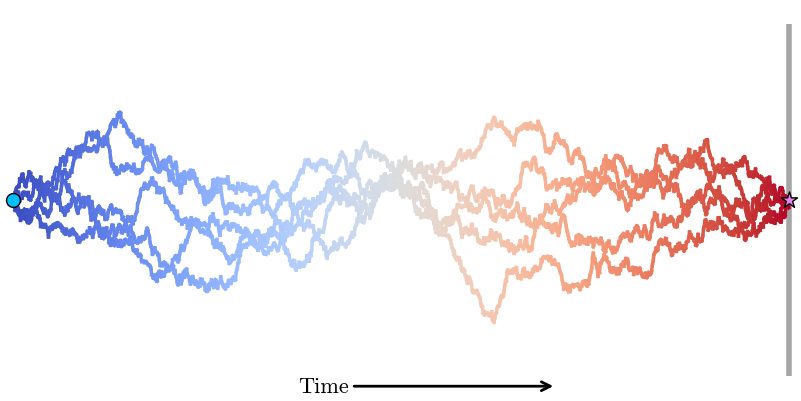

In [199]:
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
colors = plt.cm.coolwarm(jnp.linspace(0., 1., n_steps))

# Creating a time-based visualization where color indicates time progression
for i in range(n_samples):
    # Split the trajectory into segments for visualization
    for t in range(len(ts)-1):
        segment_color = colors[int(t * (len(colors) / len(ts)))]
        ax.plot(ts[t:t+2], xs_star[i, t:t+2], color=segment_color, linewidth=2.5, zorder=3)
    
ax.scatter(0.0, x0, marker='o', color='deepskyblue', s=100, edgecolors='black', zorder=10)
ax.scatter(T, xT, marker='*', color='violet', s=150, edgecolors='black', zorder=10)
ax.vlines(x=T, ymin=-1.8, ymax=1.8, color='grey', alpha=0.7, linewidth=4.0, zorder=1)
ax.set_ylim(-2.0, 2.0)
ax.set_xlim(-0.01, T + 0.01)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# Add an arrow to indicate time direction
ax.annotate('Time', xy=(0.7, -1.9), xytext=(0.4, -1.9),
                        arrowprops=dict(arrowstyle='->', lw=2, color='black'),
                        fontsize=16, ha='center', va='center')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.savefig('./assets/forward_bridge.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show() 

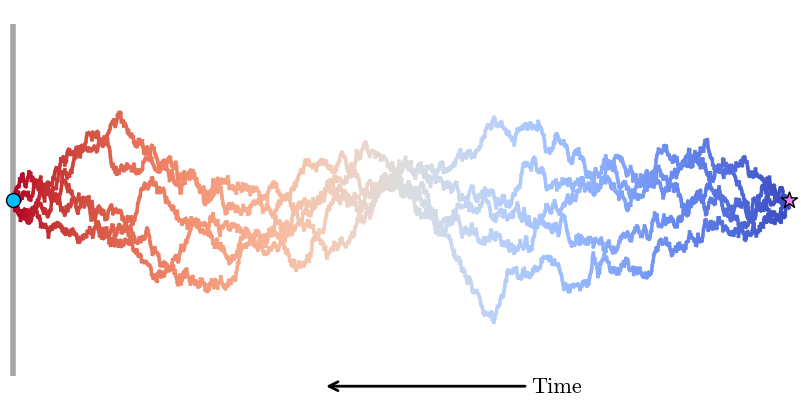

In [200]:
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
colors = plt.cm.coolwarm(jnp.linspace(0., 1., n_steps))

# Creating a time-based visualization where color indicates time progression
for i in range(n_samples):
    # Split the trajectory into segments for visualization
    for t in range(len(ts)-1):
        segment_color = colors[-int(t * (len(colors) / len(ts)))]
        ax.plot(ts[t:t+2], xs_reverse[i, t:t+2], color=segment_color, linewidth=2.5, zorder=3)
    
ax.scatter(0.0, x0, marker='o', color='deepskyblue', s=100, edgecolors='black', zorder=10)
ax.scatter(T, xT, marker='*', color='violet', s=150, edgecolors='black', zorder=10)
ax.vlines(x=0, ymin=-1.8, ymax=1.8, color='grey', alpha=0.7, linewidth=4.0, zorder=1)
ax.set_ylim(-2.0, 2.0)
ax.set_xlim(-0.01, T + 0.01)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# Add an arrow to indicate time direction
ax.annotate('Time', xy=(0.4, -1.9), xytext=(0.7, -1.9),
                        arrowprops=dict(arrowstyle='->', lw=2, color='black'),
                        fontsize=16, ha='center', va='center')

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

plt.savefig('./assets/reversed_bridge.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show() 

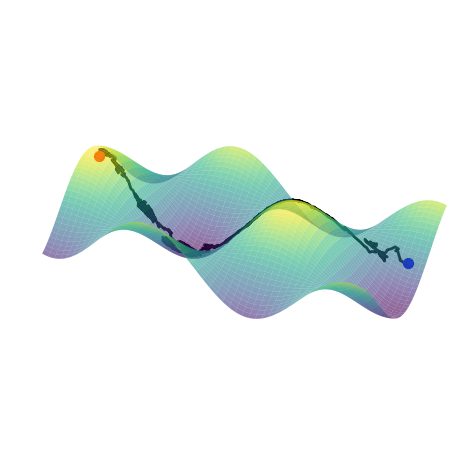

In [181]:
# Parameters
n_steps = 500
step_size = 2.0

# Define a different manifold: a Gaussian hill z = exp(-0.1*(x^2 + y^2))
def manifold_function(x, y):
    return jnp.sin(1.0 * x) * jnp.cos(0.5 * y)

def project_to_surface(xy):
    x, y = xy
    z = manifold_function(x, y)
    return jnp.array([x, y, z])

# Simulate stochastic movement on the manifold in 2D (x, y)
def simulate_brownian_bridge_on_surface(rng_key, xy0, xyT, n_steps, step_size):
    t = jnp.linspace(0, 1, n_steps + 1)
    dt = 1.0 / n_steps
    
    W = jax.random.normal(rng_key, shape=(n_steps + 1, 2)) * jnp.sqrt(dt)
    W = jnp.cumsum(W, axis=0)
    W = W - jnp.outer(t, W[-1])  # enforce bridge constraint

    xy0 = jnp.array(xy0)
    xyT = jnp.array(xyT)
    path = (1 - t)[:, None] * xy0 + t[:, None] * xyT + W * step_size
    traj = jax.vmap(project_to_surface)(path)
    return traj

# Initial point
xy0 = [-4.5, -0.5]
xyT = [4.5, 2.5]
trajectory = simulate_brownian_bridge_on_surface(rng_key, xy0, xyT, n_steps, step_size)

# Create grid for the surface
x = jnp.linspace(-5, 5, 200)
y = jnp.linspace(-5, 5, 200)
x_grid, y_grid = jnp.meshgrid(x, y)
z_grid = manifold_function(x_grid, y_grid)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis', alpha=0.6, edgecolor='none', zorder=1)

# Plot the stochastic trajectory with a thicker, highlighted line
ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], color='black', linewidth=2.0, zorder=2)
ax.scatter(trajectory[0, 0], trajectory[0, 1], trajectory[0, 2], color='red', s=50, zorder=3)
ax.scatter(trajectory[-1, 0], trajectory[-1, 1], trajectory[-1, 2], color='blue', s=50, zorder=3)
ax.axis('off')
ax.set_box_aspect([2, 1, 0.5])
fig.savefig ('./assets/stochastics_on_surface.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
x0 = jnp.stack([
    jnp.cos(jnp.linspace(0, 2 * jnp.pi, 200)),
    jnp.sin(jnp.linspace(0, 2 * jnp.pi, 200)),
], axis=-1)
print(x0.shape)

(200, 2)


In [38]:
def g_independent(t, x):
    return jnp.eye(x.shape[0]) * 0.1

def g_dependent(t, x):
    x = x.reshape(-1, 2)
    kernel = lambda dist: 0.5 * 0.1 * jnp.exp(-0.5 * jnp.sum(dist**2, axis=-1) / (0.2**2))
    dist = x[:, None, :] - x[None, :, :]
    corr_mat = kernel(dist)
    q_half = jnp.einsum('ij,kl->ikjl', corr_mat, jnp.eye(2))
    q_half = q_half.reshape(2*x.shape[0], 2*x.shape[0])
    return q_half

def f(t, x):
    return jnp.zeros_like(x)

In [33]:
def solve_sde(rng_key, f, g, x0, dt, n_steps):
    dWs = jr.normal(rng_key, shape=(n_steps, *x0.shape)) * jnp.sqrt(dt)
    
    def scan_body(carry, val):
        x, t = carry
        dW = val
        drift = f(t, x) * dt
        diffusion = g(t, x) @ dW
        x_next = x + drift + diffusion
        t_next = t + dt
        return (x_next, t_next), x_next
        
    *_, xs = jax.lax.scan(
        scan_body,
        init=(x0, 0.0),
        xs=dWs,
        length=n_steps
    )
    xs = jnp.concatenate([x0[None], xs])
    return xs

In [39]:
dt = 0.01
n_steps = 100

xs_independent = solve_sde(rng_key, f, g_independent, x0.flatten(), dt, n_steps)
xs_dependent = solve_sde(rng_key, f, g_dependent, x0.flatten(), dt, n_steps)

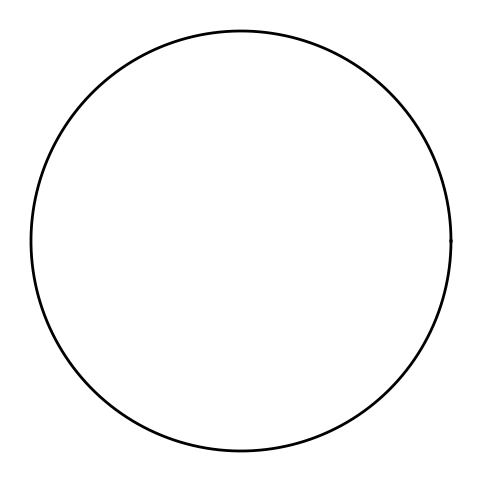

In [42]:
fig, ax = plt.subplots()
ax.plot(x0[:, 0], x0[:, 1], color='black')
ax.set_aspect('equal')
ax.set_axis_off()
fig.savefig('./assets/initial_circle.svg', format='svg', dpi=300, bbox_inches='tight')

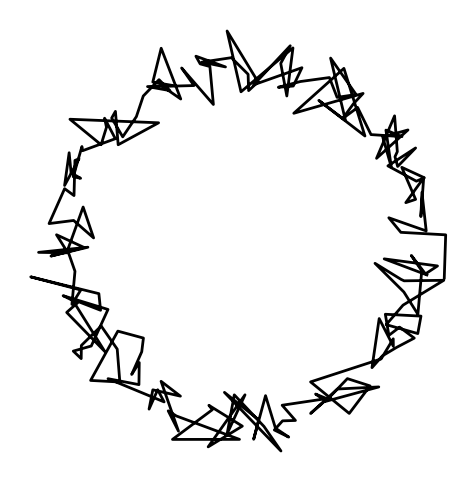

In [43]:
fig, ax = plt.subplots()
ax.plot(xs_independent[-1].reshape(-1, 2)[:, 0], xs_independent[-1].reshape(-1, 2)[:, 1], color='black')
ax.set_aspect('equal')
ax.set_axis_off()
fig.savefig('./assets/independent_circle.svg', format='svg', dpi=300, bbox_inches='tight')

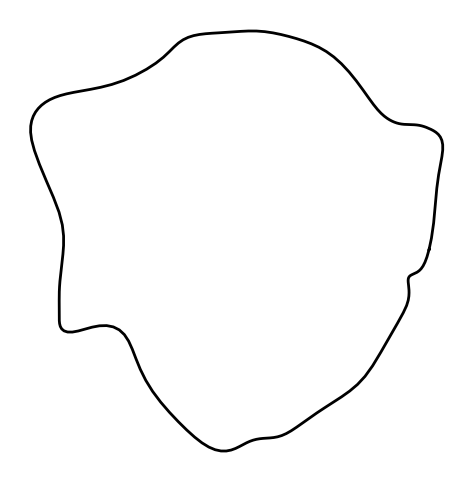

In [44]:
fig, ax = plt.subplots()
ax.plot(xs_dependent[-1].reshape(-1, 2)[:, 0], xs_dependent[-1].reshape(-1, 2)[:, 1], color='black')
ax.set_aspect('equal')
ax.set_axis_off()
fig.savefig('./assets/dependent_circle.svg', format='svg', dpi=300, bbox_inches='tight')

In [45]:
x0 = jnp.stack([
    jnp.cos(jnp.linspace(0, 2 * jnp.pi, 20)),
    jnp.sin(jnp.linspace(0, 2 * jnp.pi, 20)),
], axis=-1)

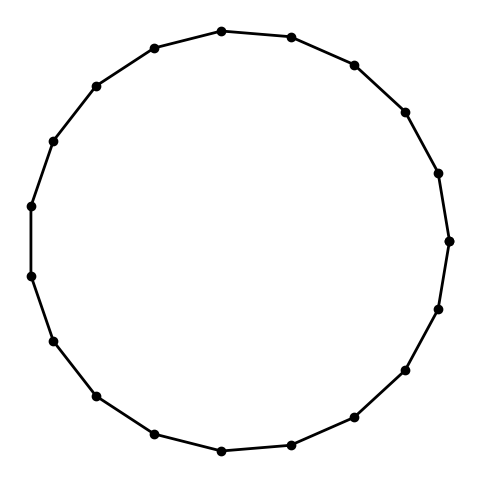

In [49]:
fig, ax = plt.subplots()
ax.plot(x0[:, 0], x0[:, 1], marker='o', color='black')
ax.set_aspect('equal')
ax.set_axis_off()
fig.savefig('./assets/circle20.svg', format='svg', dpi=300, bbox_inches='tight')

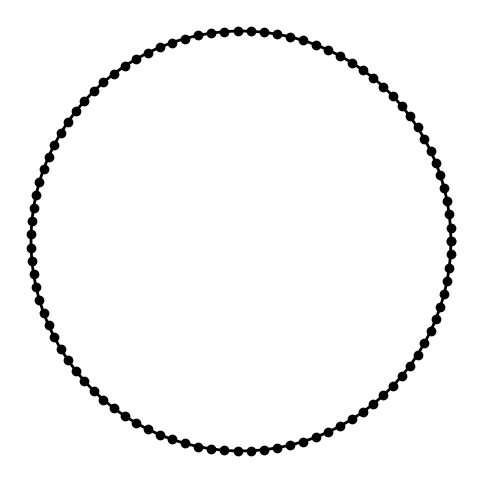

In [51]:
x0 = jnp.stack([
    jnp.cos(jnp.linspace(0, 2 * jnp.pi, 100)),
    jnp.sin(jnp.linspace(0, 2 * jnp.pi, 100)),
], axis=-1)
fig, ax = plt.subplots()
ax.plot(x0[:, 0], x0[:, 1], marker='o', color='black')
ax.set_aspect('equal')
ax.set_axis_off()
fig.savefig('./assets/circle100.svg', format='svg', dpi=300, bbox_inches='tight')